# 6 · Big data — Datashader & COG viewports

When a layer has millions of points or pixels, sending raw glyphs to the browser is hopeless. The big-data
builders aggregate **server-side** with Datashader and send an image: `rasterize` (a numeric density image,
keeps a Bokeh colorbar + live recolour), `datashade` (RGB, colour-mapped server-side), `trajectory` (shaded
GPS-style tracks) and `large_image` (loads only the visible window of a huge raster/COG at a decimated
overview, via pyramids). We use a 20 000-point synthetic cloud and the global elevation raster.

**Setup** — backends, a 20k-point cloud, three random-walk tracks, and the global elevation raster.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
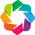

In [1]:
import warnings
warnings.filterwarnings("ignore")            # hide backend-mismatch style warnings in the docs

from pathlib import Path

# Resolve the repo root so the bundled sample data is found whether this runs from
# docs/examples/interactive/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "examples" / "data"

import io
from IPython.display import Image
import matplotlib.pyplot as plt
import holoviews as hv
hv.extension("bokeh", "matplotlib")          # Bokeh = interactive; matplotlib = static (projection/barbs)

def show(m, static=False, dpi=96):
    """Display the map — **interactive Bokeh** by default (pan / zoom / hover).

    RUN THIS NOTEBOOK (Run All / Shift-Enter) to see the live interactive maps: a saved .ipynb only
    shows interactive plots once the viewer executes their JavaScript (a running kernel, or a trusted
    notebook). Pass ``static=True`` (used for the matplotlib-only layers — projection, streamlines,
    wind barbs, which have no Bokeh glyph) to render a static PNG instead.
    """
    if static or getattr(m, "_projection", None) is not None:
        fig = hv.render(m.render(), backend="matplotlib")
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
        plt.close(fig)
        return Image(data=buf.getvalue())
    return m.render()                        # interactive Bokeh object

import numpy as np, geopandas as gpd, pandas as pd
from pyramids.dataset import Dataset
from digitalearth.interactive import InteractiveMap

rng = np.random.default_rng(0)
N = 20_000
cloud = gpd.GeoDataFrame(
    {"value": rng.normal(10, 2, N)},
    geometry=gpd.points_from_xy(rng.uniform(6.0e5, 9.0e5, N), rng.uniform(6.2e6, 6.5e6, N)),
    crs="EPSG:3857",
)
_frames = []
for tid in ("t1", "t2", "t3"):
    s = rng.normal(0, 4000.0, size=(700, 2)).cumsum(axis=0)
    _frames.append(pd.DataFrame({"x": 7.6e5 + s[:, 0], "y": 6.35e6 + s[:, 1], "track": tid}))
_t = pd.concat(_frames, ignore_index=True)
tracks = gpd.GeoDataFrame(_t[["track"]], geometry=gpd.points_from_xy(_t.x, _t.y), crs="EPSG:3857")

# Global elevation lives in the gitignored examples/data/global/; None when the sample is absent
# (CI / a fresh clone), in which case the large_image cell below skips.
_elev_path = DATA / "global" / "wc2.1_10m_elev.tif"
elev = Dataset.read_file(str(_elev_path)) if _elev_path.exists() else None

### `rasterize` — a numeric density image
Aggregate the 20k points to a fixed canvas. `dynamic=False` gives a deterministic static image; in a live server it re-aggregates on zoom and keeps a colorbar.

In [2]:
m = InteractiveMap(crs=3857, title="20k points → rasterize (count)")
m.rasterize(cloud, aggregator="count", dynamic=False, width=300, height=200)
show(m)

:Image   [Longitude,Latitude]   (Count)

### `datashade` — server-side colour mapping
Like `rasterize` but the colour mapping also happens server-side, so it returns an RGB image (very fast for huge clouds).

In [3]:
m = InteractiveMap(crs=3857, title="20k points → datashade")
m.datashade(cloud, cmap="fire", dynamic=False, width=300, height=200)
show(m)

:RGB   [Longitude,Latitude]   (R,G,B,A)

### `trajectory` — shaded tracks
Shade many GPS-style tracks, coloured by `track` id, into one RGB layer.

In [4]:
m = InteractiveMap(crs=3857, title="three tracks (trajectory)")
m.trajectory(tracks, track_column="track", dynamic=False, width=300, height=200)
show(m)

:RGB   [x,y]   (R,G,B,A)

### `large_image` — viewport-loaded COG
Instead of materialising a multi-GB raster, `large_image` reads only the visible window at a suitable overview via pyramids (`preview`/`read_part`). `dynamic=False` renders one decimated preview frame; in a live server it re-reads on pan/zoom. (`band` is 1-based.)

In [5]:
if elev is not None:
    m = InteractiveMap(crs=elev.epsg, title="global elevation (large_image preview)")
    m.large_image(elev, dynamic=False, max_pixels=200 * 200, cmap="terrain")
    display(show(m))
else:
    print("skipped — the WorldClim sample (examples/data/global/) is not bundled with the repo")

:Image   [x,y]   (z)